<a href="https://colab.research.google.com/github/T-Y-Li/Colab/blob/main/HandwrittenDigitRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow版本：", tf.__version__)

TensorFlow版本： 2.20.0


In [2]:
# 載入 MNIST 資料集
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("訓練圖片數量：", x_train.shape)
print("測試圖片數量：", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
訓練圖片數量： (60000, 28, 28)
測試圖片數量： (10000, 28, 28)


In [3]:
# plt.imshow(x_train[0], cmap="gray")
# plt.title(f"Answer: {y_train[0]}")
# plt.axis("off")
# plt.show()

In [4]:
# 將像素值轉成 0～1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 增加灰階通道
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("整理後的訓練資料：", x_train.shape)

整理後的訓練資料： (60000, 28, 28, 1)


In [5]:
model = tf.keras.Sequential([
    # 第一層卷積：找出線條、邊緣等特徵
    tf.keras.layers.Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    # 縮小圖片，保留重要特徵
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # 第二層卷積
    tf.keras.layers.Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # 將二維特徵轉成一維
    tf.keras.layers.Flatten(),

    # 全連接層
    tf.keras.layers.Dense(128, activation="relu"),

    # 避免模型過度記住訓練資料
    tf.keras.layers.Dropout(0.3),

    # 輸出 0～9 共十種結果
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.9198 - loss: 0.2602 - val_accuracy: 0.9808 - val_loss: 0.0617
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.9767 - loss: 0.0768 - val_accuracy: 0.9877 - val_loss: 0.0443
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 58ms/step - accuracy: 0.9839 - loss: 0.0522 - val_accuracy: 0.9895 - val_loss: 0.0372
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.9851 - loss: 0.0449 - val_accuracy: 0.9910 - val_loss: 0.0332
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.9888 - loss: 0.0371 - val_accuracy: 0.9915 - val_loss: 0.0327


In [7]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("測試資料損失值：", test_loss)
print("測試資料正確率：", test_accuracy)

測試資料損失值： 0.02574775367975235
測試資料正確率： 0.9902999997138977


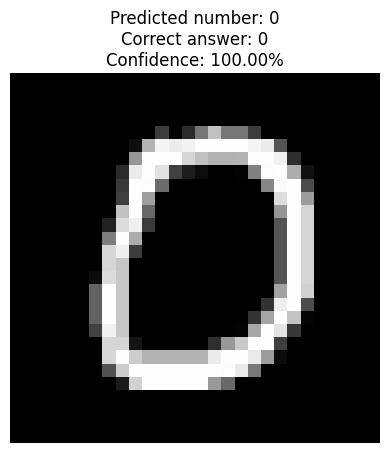

In [8]:
image_index = 10

image = x_test[image_index]
correct_answer = y_test[image_index]

# 模型需要一次接收一批圖片，因此增加一個維度
prediction = model.predict(
    np.expand_dims(image, axis=0),
    verbose=0
)

predicted_number = np.argmax(prediction)
confidence = np.max(prediction)

plt.imshow(image.squeeze(), cmap="gray")
plt.title(
    f"Predicted number: {predicted_number}\n"
    f"Correct answer: {correct_answer}\n"
    f"Confidence: {confidence:.2%}"
)
plt.axis("off")
plt.show()

In [9]:
from google.colab import files
from PIL import Image, ImageOps
import io

In [10]:
uploaded = files.upload()

file_name = next(iter(uploaded))

# 讀取圖片並轉成灰階
image = Image.open(io.BytesIO(uploaded[file_name])).convert("L")

# 調整成 28×28
image = image.resize((28, 28))

# 轉成 NumPy 陣列
image_array = np.array(image)

Saving 截圖 2026-09-03 下午3.20.57.png to 截圖 2026-09-03 下午3.20.57.png


In [11]:
# 若圖片整體偏亮，代表可能是白底黑字，將顏色反轉
if image_array.mean() > 127:
    image_array = 255 - image_array

# 像素值轉成 0～1
image_array = image_array.astype("float32") / 255.0

# 改成模型需要的形狀：(1, 28, 28, 1)
model_input = image_array.reshape(1, 28, 28, 1)

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36776 (\N{CJK UNIFIED IDEOGRAPH-8FA8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figu

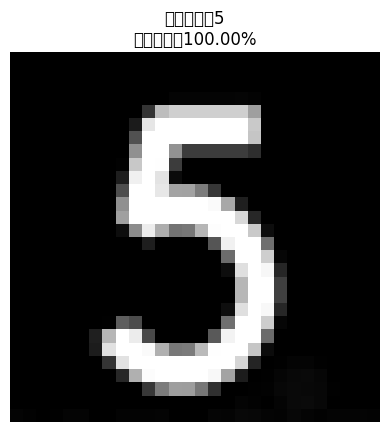

模型認為這個數字是： 5
信心程度： 100.00%


In [12]:
prediction = model.predict(model_input, verbose=0)

predicted_number = np.argmax(prediction)
confidence = np.max(prediction)

plt.imshow(image_array, cmap="gray")
plt.title(
    f"辨識結果：{predicted_number}\n"
    f"信心程度：{confidence:.2%}"
)
plt.axis("off")
plt.show()

print("模型認為這個數字是：", predicted_number)
print("信心程度：", f"{confidence:.2%}")

In [13]:
for number, probability in enumerate(prediction[0]):
    print(f"數字 {number}：{probability:.2%}")

數字 0：0.00%
數字 1：0.00%
數字 2：0.00%
數字 3：0.00%
數字 4：0.00%
數字 5：100.00%
數字 6：0.00%
數字 7：0.00%
數字 8：0.00%
數字 9：0.00%


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38928 (\N{CJK UNIFIED IDEOGRAPH-9810}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27231 (\N{CJK UNIFIED IDEOGRAPH-6A5F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  fig.canvas

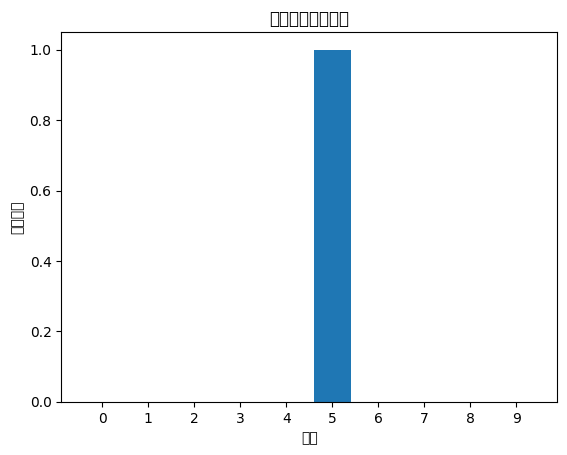

In [14]:
plt.bar(range(10), prediction[0])
plt.xticks(range(10))
plt.xlabel("數字")
plt.ylabel("預測機率")
plt.title("各數字的預測機率")
plt.show()

In [15]:
model.save("handwritten_digit_model.keras")
print("模型儲存完成")

files.download("handwritten_digit_model.keras")

model = tf.keras.models.load_model("handwritten_digit_model.keras")

模型儲存完成


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>